### Creation of Simulation Models

As previously shown, we will use the transformers pipeline to create the simulation model of a spring-damper system using scipy. 


In [ ]:
from transformers import AutoTokenizer, pipeline
from huggingface_hub import hf_hub_download
import torch # only used to check if cuda is availible
import time
from LLMHelperFunctions import CheckOutputLLM # helper function


MODEL_ID = "google/gemma-4-E2B-it" # approx 10GB disk size
pipe = pipeline(
        task="any-to-any",
        model=MODEL_ID,
        device_map="auto",
        dtype="auto"
)

### Input Formatting
For the used Gemma4 model the prompt format is:   
myInput = f"<|turn>user\n ...  
            <|turn>model\n"  
is used (see also [here](https://ai.google.dev/gemma/docs/core/huggingface_inference)). Note that other models might use different formats.

The model continues as the assistent and stops with token <turn|>. Alternatively the message format can be used as shown in the following. 

Note that models are trained to prioritize system prompt over user - e.g. to provide guardrails. 

In [ ]:
# Open the file in read mode and save its content to the variable 'data'
with open("Prompt_Osci.txt", "r") as file:
    prompt = file.read()
print('prompt:\n', prompt)

messages = [
    {
        "role": "system", 
        "content": [{"type": "text", "text": "You are an expert in multibody dynamics and assist in creating dynamic models."}]
    },
    {
        "role": "user",
        "content": [{"type": "text", "text": prompt}]
    },]

prompt:
 Create Python code for a 2-mass spring-damper with m1=1kg, m2=5kg, k1=k2=1600N/m and d1=d2=8Nm/s using scipy. The initial displacement and Velocity shall be 0 for both masses, but on the second mass a force F=100*np.sin(t) should act. Plot the displacements of both masses. 
Create only the code and no additional output. 


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
def count_tokens(messages):
    text = ""
    for msg in messages:
        for item in msg["content"]:
            text += item["text"] + "\n"

    return len(tokenizer(text)["input_ids"])
num_tokens = count_tokens(messages)
print("Number of input tokens:", num_tokens)

Number of input tokens: 124


In [ ]:
print('prompt formatted: ', messages[0]['content'][0]['text'])
print(messages[1]['content'][0]['text'])

prompt formatted:  You are an expert in multibody dynamics and assist in creating dynamic models.
Create Python code for a 2-mass spring-damper with m1=1kg, m2=5kg, k1=k2=1600N/m and d1=d2=8Nm/s using scipy. The initial displacement and Velocity shall be 0 for both masses, but on the second mass a force F=100*np.sin(t) should act. Plot the displacements of both masses. 
Create only the code and no additional output. 


### Code Generation

Now, the actual simulation code is created by the language model. This might take a bit.  
If the local model does not have good performance, you can also use an online interface as e.g., [chatgpt](https://chatgpt.com/) or [gemini](https://gemini.google.com) as shown in the API example.



In [ ]:
t1 = time.time()
print('start generation... ') # this might take a while
output = pipe(messages, max_new_tokens=int(2048) ) # generate output
dt = time.time() - t1
print(output)
print('dt=',dt)


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


start generation... 


[transformers] Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'input_text': [{'role': 'system', 'content': [{'type': 'text', 'text': 'You are an expert in multibody dynamics and assist in creating dynamic models.'}]}, {'role': 'user', 'content': [{'type': 'text', 'text': 'Create Python code for a 2-mass spring-damper with m1=1kg, m2=5kg, k1=k2=1600N/m and d1=d2=8Nm/s using scipy. The initial displacement and Velocity shall be 0 for both masses, but on the second mass a force F=100*np.sin(t) should act. Plot the displacements of both masses. \nCreate only the code and no additional output. '}]}], 'generated_text': [{'role': 'system', 'content': [{'type': 'text', 'text': 'You are an expert in multibody dynamics and assist in creating dynamic models.'}]}, {'role': 'user', 'content': [{'type': 'text', 'text': 'Create Python code for a 2-mass spring-damper with m1=1kg, m2=5kg, k1=k2=1600N/m and d1=d2=8Nm/s using scipy. The initial displacement and Velocity shall be 0 for both masses, but on the second mass a force F=100*np.sin(t) should act. Plot th

In [ ]:
strOutput = output[0]['generated_text'][2]['content']
print(strOutput)
# note: in the next step, the python code needs to be extracted and executed. 
# The prompt should already include instructions to only output python code to avoid additional text. Older LLMs might not follow this instruction. 


```python
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def mass_spring_damper(t, y, m1, m2, k1, k2, d1, d2, F_external):
    """
    System of first-order ODEs for the 2-mass spring-damper system.

    y = [x1, x1_dot, x2, x2_dot]
    """
    x1, v1, x2, v2 = y

    # Equations of motion:
    # m1*x1_ddot = -k1*x1 - d1*v1 + coupling_force
    # m2*x2_ddot = -k2*x2 - d2*v2 + coupling_force

    # For this problem, we assume a simple coupled system where the force F acts only on m2.
    # Assuming a simple spring connection between m1 and m2 (which is common, but not explicitly defined).
    # Since the prompt only specifies an external force on m2, we model it as:

    # Force on m1: F1 = -k1*x1 - d1*v1
    # Force on m2: F2 = -k2*x2 - d2*v2 + F_external

    # Accelerations:
    a1 = (-k1 * x1 - d1 * v1) / m1
    a2 = (-k2 * x2 - d2 * v2 + F_external) / m2

    # Derivatives:
    dx1_dt = v1
    dv1_dt = a1
    dx2_dt = v2
    dv2_dt = a2

 

### Code Extraction

    
The typical models tend to provide explanations for the code not only as comments but also before and after. The code tags __```__ help to locate the code as part of the output, but not all models might use them. Alternatively, one could also instruct the model to use e.g., HTML tags. 


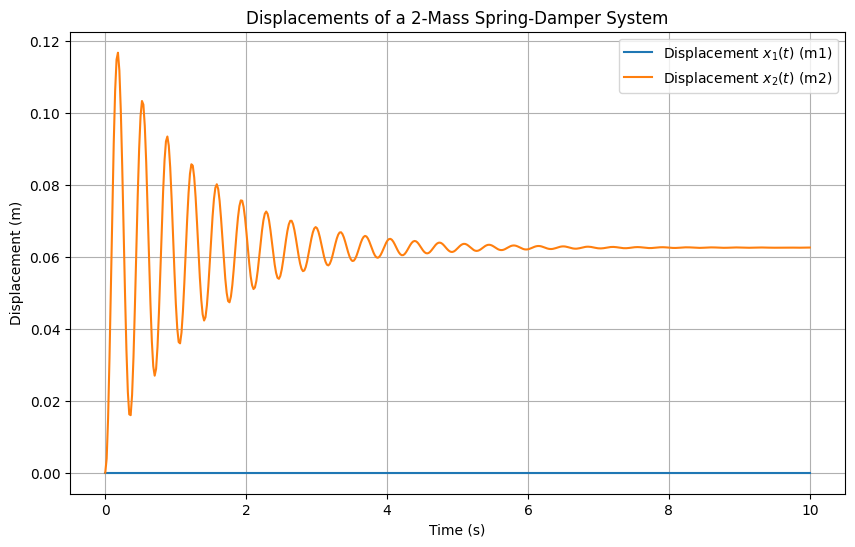

In [ ]:
pythonCode = strOutput.split('```python')[1].split('```')[0] # extract code from output

# Be careful: code execution is a potential safety risk as it is directly executed and not reviewed. 
# To avoid (some) issues, the CheckOutputLLM helper function checks if some 
CheckOutputLLM(pythonCode)

exec(pythonCode) 


## Task (10 minutes)
- Check the code and validate if the created simulation model is correct. 
- Think of a different simple mechanical system, create a prompt as a .txt file and run the notebook with it. 